In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
df=pd.read_csv("Combined Data.CSV")
df.tail()


,Unnamed: 0,statement,status
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety
53042,53042,I have really bad door anxiety! It's not about...,Anxiety


In [26]:
risk_map_lower = {
    # High Risk categories
    "anxiety": "High Risk",
    "stress": "High Risk",
    "depression": "High Risk",
    "suicidal": "High Risk",
    "bipolar": "High Risk",
    "personality disorder": "High Risk",
    
    # Stable/Low Risk categories
    "normal": "Stable",
    "okay": "Stable",
    "fine": "Stable",
    
    "good": "stable",
    "happy": "Stable",
    "calm": "Stable",
    "excited" : "Stable",
}




In [27]:
df["risk_level"] = df["status"].astype(str).str.lower().map(risk_map_lower)

In [28]:
df["risk_level"] = df["risk_level"].fillna("Stable")

In [29]:
df.head()

,Unnamed: 0,statement,status,risk_level
0,0,oh my gosh,Anxiety,High Risk
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,High Risk
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,High Risk
3,3,I've shifted my focus to something else but I'...,Anxiety,High Risk
4,4,"I'm restless and restless, it's been a month n...",Anxiety,High Risk


In [30]:
df.head()

,Unnamed: 0,statement,status,risk_level
0,0,oh my gosh,Anxiety,High Risk
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,High Risk
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,High Risk
3,3,I've shifted my focus to something else but I'...,Anxiety,High Risk
4,4,"I'm restless and restless, it's been a month n...",Anxiety,High Risk


In [31]:
print("class Distribution:",Counter(df["risk_level"]))

class Distribution: Counter({'High Risk': 36692, 'Stable': 16351})


In [32]:
X_train,X_test,y_train,y_test=train_test_split(
    df["statement"], df["risk_level"], test_size=0.2, random_state=42,stratify=df["risk_level"])
print("Training set size:",X_train.shape)
print("Training test size:",X_test.shape)


Training set size: (42434,)
Training test size: (10609,)


In [33]:
df = df.dropna(subset=["statement"])


In [34]:
df.head()

,Unnamed: 0,statement,status,risk_level
0,0,oh my gosh,Anxiety,High Risk
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,High Risk
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,High Risk
3,3,I've shifted my focus to something else but I'...,Anxiety,High Risk
4,4,"I'm restless and restless, it's been a month n...",Anxiety,High Risk


In [35]:
print(df[df["statement"].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, statement, status, risk_level]
Index: []


In [36]:
print(X_train.apply(type).value_counts())


statement
<class 'str'>      42135
<class 'float'>      299
Name: count, dtype: int64


In [37]:
X_train

21638    it is 2AM and I am so close to falling asleep....
5728     â€œYou want to be respected but you look down ...
16461    where can i buy a suicide/exit bag in the UK. ...
41844    maddyva thanks a lot learned a lot of new word...
39895    my girlfriend finally left me my depression dr...
                               ...                        
51877    Hurry sickness is driving me crazy. Does anyon...
50193    i hate the way media depicts mania i (16ENBY) ...
11473    it will never get better for me its just a cyc...
26640    Trigger warNING!! MenTION of suicIDAL thougHTS...
6662                                   hiccups maybe drink
Name: statement, Length: 42434, dtype: object

In [38]:
y_train

21638    High Risk
5728        Stable
16461    High Risk
41844       Stable
39895    High Risk
           ...    
51877    High Risk
50193    High Risk
11473    High Risk
26640    High Risk
6662        Stable
Name: risk_level, Length: 42434, dtype: object

In [39]:
# Convert all values in statement column to string
X_train = X_train.astype(str)
X_test = X_test.astype(str)


In [40]:
vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [41]:
model=LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42 )
model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [42]:
import joblib

#Saves the trained TF-IDF vectorizer 
joblib.dump(vectorizer, 'vectorizer.joblib')

# Saves the trained model
joblib.dump(model, 'model.joblib')

['model.joblib']

In [43]:
##prediction and Evaluation
y_pred =model.predict(X_test_vec)
accuracy = accuracy_score(y_test,y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report: \n",classification_report(y_test,y_pred))


Model Accuracy: 0.9360

Classification Report: 
               precision    recall  f1-score   support

   High Risk       0.98      0.93      0.95      7339
      Stable       0.86      0.95      0.90      3270

    accuracy                           0.94     10609
   macro avg       0.92      0.94      0.93     10609
weighted avg       0.94      0.94      0.94     10609



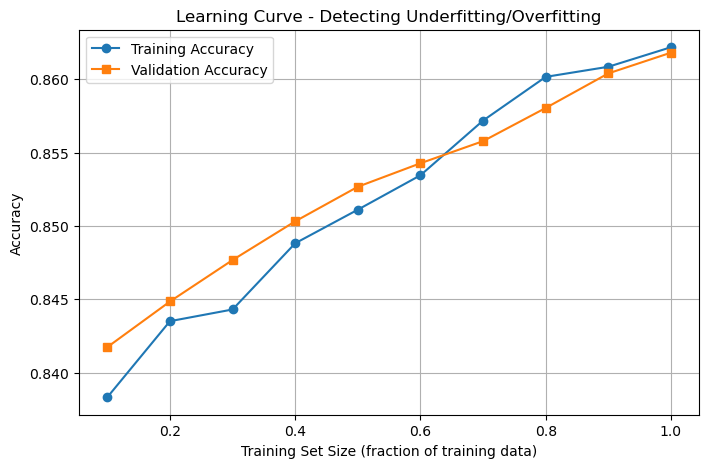

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Visualize underfitting vs overfitting using learning curves
train_sizes = np.linspace(0.1, 1.0, 10)
train_accuracies = []
test_accuracies = []

for train_size in train_sizes:
    # Use increasing portions of training data
    X_part = X_train_vec[:int(train_size * X_train_vec.shape[0])]
    y_part = y_train[:int(train_size * len(y_train))]

    model_lc = LogisticRegression(max_iter=1000, C=0.01, class_weight='balanced', random_state=42)
    model_lc.fit(X_part, y_part)

    y_train_pred = model_lc.predict(X_part)
    y_test_pred = model_lc.predict(X_test_vec)

    train_accuracies.append(accuracy_score(y_part, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))
# Plot learning curve
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_accuracies, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_accuracies, label="Validation Accuracy", marker='s')
plt.title("Learning Curve - Detecting Underfitting/Overfitting")
plt.xlabel("Training Set Size (fraction of training data)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
